In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [54]:
import importlib
import forecasting_utils

importlib.reload(forecasting_utils)

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from forecasting_utils import (
    FOCUS_AGES,
    add_lag_features,
    build_daily_arrivals,
    clean_opossum_data,
    evaluate_regression,
    feature_columns,
    forecast_date_range,
    recursive_forecast,
    save_csv,
    split_for_2026_forecast,
    zero_before_season_start,
)

# Supervised Modeling

This notebook applies feature-based regressors to the daily arrival forecasting frame.


In [55]:
df = clean_opossum_data()
forecast_end_date = pd.Timestamp("2026-06-01")
daily_df = build_daily_arrivals(df, focus_ages=FOCUS_AGES)
observed_end_date = daily_df["admission_date"].max()
future_horizon_days = max(0, (forecast_end_date - observed_end_date).days)
future_dates = forecast_date_range(observed_end_date, future_horizon_days)
future_frame = pd.DataFrame({"admission_date": future_dates, "arrivals": np.nan})

model_df = add_lag_features(daily_df).dropna().reset_index(drop=True)
splits = split_for_2026_forecast(model_df)

features = feature_columns(model_df)

X_train = splits.train[features]
y_train = splits.train["arrivals"]
X_valid = splits.validation[features]
y_valid = splits.validation["arrivals"]
X_test = splits.test[features]
y_test = splits.test["arrivals"]

In [56]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
    ),
}

In [57]:
results = []
observed_predictions = splits.test[["admission_date", "arrivals"]].copy()
future_predictions = future_frame.copy()

for model_name, model in models.items():
    model.fit(X_train, y_train)
    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)
    test_pred = zero_before_season_start(
        splits.test[["admission_date"]].assign(model_pred=test_pred),
        ["model_pred"],
    )["model_pred"].to_numpy()

    results.append(evaluate_regression(y_valid, valid_pred, f"{model_name} (2025 validation)"))
    results.append(evaluate_regression(y_test, test_pred, f"{model_name} (2026 test)"))
    observed_predictions[f"{model_name}_pred"] = test_pred

    full_model = clone(model)
    full_model.fit(model_df[features], model_df["arrivals"])
    future_rows = recursive_forecast(full_model, daily_df, future_dates, features)
    future_pred = zero_before_season_start(
        future_rows[["admission_date"]].assign(model_pred=future_rows["arrivals"].to_numpy()),
        ["model_pred"],
    )["model_pred"].to_numpy()
    future_predictions[f"{model_name}_pred"] = future_pred

predictions = pd.concat([observed_predictions, future_predictions], ignore_index=True)

results_df = pd.DataFrame(results)
results_df.sort_values(["rmse", "mae"])

,model,mae,rmse,mape
5,XGBoost (2026 test),0.166773,0.555234,99.187980
1,LinearRegression (2026 test),0.268220,0.621684,94.877183
3,RandomForest (2026 test),0.319929,0.717576,98.416362
2,RandomForest (2025 validation),1.902518,3.426729,78.439838
0,LinearRegression (2025 validation),1.899498,3.472053,78.761486
4,XGBoost (2025 validation),1.941450,3.526612,85.795789


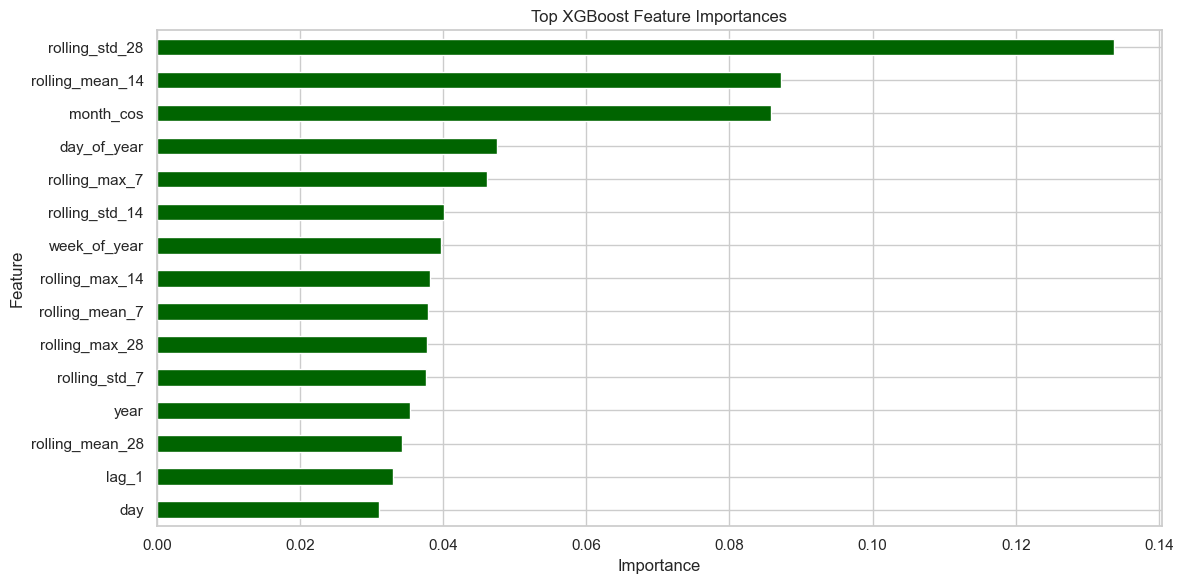

In [58]:
xgb_model = models["XGBoost"]
importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False).head(15)
importance.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

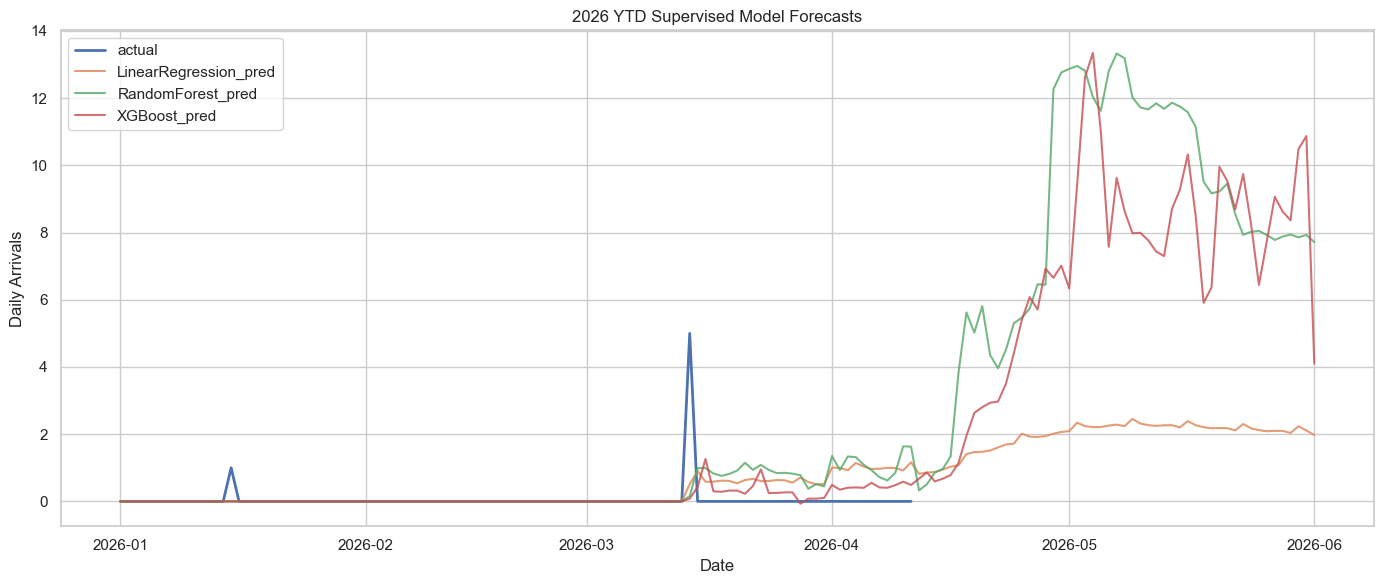

In [59]:
plt.figure(figsize=(14, 6))
plt.plot(predictions["admission_date"], predictions["arrivals"], label="actual", linewidth=2)
for column in predictions.columns:
    if column.endswith("_pred"):
        plt.plot(predictions["admission_date"], predictions[column], label=column, alpha=0.8)
plt.title("2026 YTD Supervised Model Forecasts")
plt.xlabel("Date")
plt.ylabel("Daily Arrivals")
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
save_csv(results_df, "supervised_model_metrics.csv")
save_csv(predictions, "supervised_model_predictions.csv")

WindowsPath('C:/Users/Owner/PycharmProjects/opos_prediction/data/processed/supervised_model_predictions.csv')